In [2]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Práctica: Preprocesamiento de Datos

## Librerías y configuración

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías listas para usarse.")

Librerías listas para usarse.


# 1) Carga universal del dataset

In [4]:
# 1.1 Ruta del archivo (ajuste)
DATA_PATH = "train.csv"  # <-- Asegúrate de que el archivo descargado esté en la misma carpeta que tu código

# 1.2 Seleccione el tipo de archivo 
# --- Opción A: CSV con separador y codificación explícita ---
df = pd.read_csv(DATA_PATH, sep=",", encoding="utf-8")

# Verificación mínima
display(df.head())
print("Shape:", df.shape)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Shape: (891, 12)


# 2) Vista rápida y perfil inicial (Data Quality)

In [5]:

# 2.1 Resumen rápido
print("--- 2.1 Resumen Rápido ---")
display(df.head())
print("Filas, Columnas:", df.shape)
display(df.sample(min(5, len(df)), random_state=7))

# 2.2 Tipos y nulos
print("\n--- 2.2 Tipos de datos y Valores Nulos ---")
display(df.dtypes)
display(df.isna().sum().sort_values(ascending=False).head(20))

# 2.3 Estadística numérica
print("\n--- 2.3 Estadística Numérica ---")
display(df.describe(include=[np.number]).T)

# 2.4 Estadística categórica
print("\n--- 2.4 Estadística Categórica ---")
display(df.describe(include=["object", "category"]).T.head(20))

# ==========================================
# 2.5 Detección de columnas de fecha/hora (opcional)
# ==========================================
# ACTIVIDAD: Identifique columnas de fecha y conviértalas si aplica.
# Respuesta: El dataset del Titanic NO contiene columnas de fecha, por lo que este paso se omite.

--- 2.1 Resumen Rápido ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Filas, Columnas: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
725,726,0,3,"Oreskovic, Mr. Luka",male,20.0,0,0,315094,8.6625,NaN,S
861,862,0,2,"Giles, Mr. Frederick Edward",male,21.0,1,0,28134,11.5000,NaN,S
528,529,0,3,"Salonen, Mr. Johan Werner",male,39.0,0,0,3101296,7.9250,NaN,S
46,47,0,3,"Lennon, Mr. Denis",male,NaN,1,0,370371,15.5000,NaN,Q
627,628,1,1,"Longley, Miss. Gretchen Fiske",female,21.0,0,0,13502,77.9583,D9,S



--- 2.2 Tipos de datos y Valores Nulos ---


...

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


--- 2.3 Estadística Numérica ---


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



--- 2.4 Estadística Categórica ---


,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


# 3) Data Cleaning — Valores faltantes (Missing Values)

In [6]:

# 3.1 Identificar columnas por tipo
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# Creamos una copia para empezar a limpiar
df_clean = df.copy()

# ==========================================
# ACTIVIDAD: Elija una estrategia por tipo de variable y justifique.
# ==========================================

# ESTRATEGIA 1: Opción B (Eliminar columnas con demasiados nulos)
# Justificación: 'Cabin' tiene ~77% de nulos. Rellenarla inventando datos introduciría mucho ruido.
threshold = 0.5  # elimina columnas con >50% nulos
to_drop = [c for c in df_clean.columns if df_clean[c].isna().mean() > threshold]
df_clean = df_clean.drop(columns=to_drop)
print(f"\nColumnas eliminadas por exceso de nulos: {to_drop}")

# ESTRATEGIA 2: Opción C (Imputación simple para el resto)
# Justificación: 
# - Para numéricas ('Age'), usamos la mediana porque no se afecta por valores extremos (outliers).
# - Para categóricas ('Embarked'), usamos la moda (el valor más frecuente) porque solo faltan 2 datos.

# --- Numéricas: Rellenar con la mediana ---
# Actualizamos num_cols por si se borró alguna numérica
num_cols_clean = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols_clean:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# --- Categóricas: Rellenar con la moda ---
# Actualizamos cat_cols por si se borró alguna categórica (como 'Cabin')
cat_cols_clean = df_clean.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
for c in cat_cols_clean:
    if df_clean[c].isna().any():
        moda = df_clean[c].mode(dropna=True)
        if len(moda) > 0:
            df_clean[c] = df_clean[c].fillna(moda.iloc[0])
        else:
            df_clean[c] = df_clean[c].fillna("DESCONOCIDO")

# Verificación Final del Paso 3
print("\nNulos después de la limpieza:", df_clean.isna().sum().sum())
display(df_clean.head())

Numéricas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categóricas: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Columnas eliminadas por exceso de nulos: ['Cabin']

Nulos después de la limpieza: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# 4) Data Cleaning — Ruido, outliers y formatos (Noisy Data)

--- Antes del tratamiento de Outliers ---


,count,mean,std,min,25%,50%,75%,max
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292
Age,891.0,29.361582,13.019697,0.42,22.0000,28.0000,35.0,80.0000


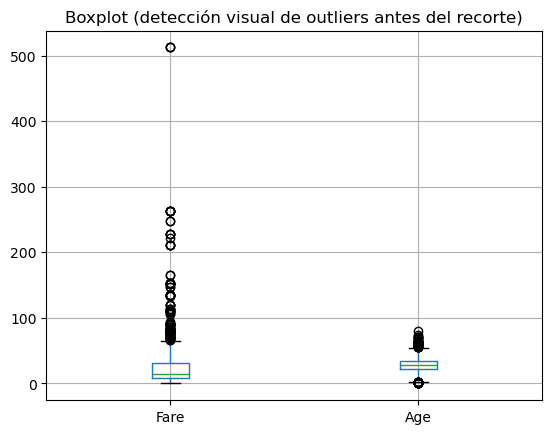


--- Después del tratamiento de Outliers (Winsorizing) ---


,count,mean,std,min,25%,50%,75%,max
Fare,891.0,24.046813,20.481625,0.0,7.9104,14.4542,31.0,65.6344
Age,891.0,29.039282,12.072074,2.5,22.0000,28.0000,35.0,54.5000



--- Categorías limpias en 'Embarked' ---


Embarked
southampton    646
cherbourg      168
queenstown      77
Name: count, dtype: int64

In [7]:
# Seleccionamos las columnas numéricas donde buscaremos outliers
cols_check = ["Fare", "Age"]  

print("--- Antes del tratamiento de Outliers ---")
display(df_clean[cols_check].describe().T)

# Visualización rápida (boxplot)
df_clean[cols_check].boxplot()
plt.title("Boxplot (detección visual de outliers antes del recorte)")
plt.show()

# 4.1 Función para detectar límites usando el Rango Intercuartílico (IQR)
def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

# ESTRATEGIA: Opción B: Cap/Winsorize (recortar a límites)
# Justificación: No queremos borrar al pasajero que pagó $512 porque su información de si 
# sobrevivió o no es útil. Mejor "topamos" su tarifa al límite máximo aceptable.
df_clean2 = df_clean.copy() 

for c in cols_check:
    lo, hi = iqr_bounds(df_clean2[c].dropna())
    df_clean2[c] = df_clean2[c].clip(lower=lo, upper=hi)

print("\n--- Después del tratamiento de Outliers (Winsorizing) ---")
display(df_clean2[cols_check].describe().T)


# ==========================================
# 4.2 Limpieza de categorías inconsistentes 
# ==========================================

# Vamos a mejorar la columna 'Embarked' (Puerto de embarque) que solo tiene letras (C, Q, S)
col_cat = "Embarked"

# Normalización básica (quitamos espacios extra y pasamos a minúsculas)
df_clean2[col_cat] = df_clean2[col_cat].astype(str).str.strip().str.lower()

# Mapeo manual para darle formato y significado real
mapa_puertos = {
    "s": "southampton", 
    "c": "cherbourg", 
    "q": "queenstown"
}
df_clean2[col_cat] = df_clean2[col_cat].replace(mapa_puertos)

# Ver antes/después
print("\n--- Categorías limpias en 'Embarked' ---")
display(df_clean2[col_cat].value_counts())

# 5) Data Integration — Unión de fuentes (opcional)

In [9]:

# ACTIVIDAD: Si NO integra, escriba: “No aplica: solo se usó una fuente”.
print("--- 5.1 y 5.2 Unión de fuentes ---")
print("Respuesta: No aplica: solo se usó una fuente (dataset Titanic).")

# ==========================================
# 5.3 Duplicación de tuplas (duplicados)
# ==========================================
# Aunque es una sola fuente, verificamos que no haya filas idénticas repetidas por error.

base = df_clean2  
dup_rows = base.duplicated().sum()
print(f"\nDuplicados exactos encontrados: {dup_rows}")

# Código preventivo para eliminar duplicados exactos (si los hubiera)
df_nodup = base.drop_duplicates().copy()
print(f"Shape final tras revisión de duplicados: {df_nodup.shape}")

--- 5.1 y 5.2 Unión de fuentes ---
Respuesta: No aplica: solo se usó una fuente (dataset Titanic).

Duplicados exactos encontrados: 0
Shape final tras revisión de duplicados: (891, 11)


# 6) Data Reduction — Reducción de datos

In [10]:
# Usamos el dataset limpio y sin duplicados del paso 5
base = base_nodup 

# ==========================================
# 6.1 Selección de atributos (manual)
# ==========================================
# Vamos a conservar solo las columnas que tienen un impacto real en la supervivencia.
# Descartamos: 'PassengerId', 'Name' (Nombre) y 'Ticket' (Número de boleto).

keep = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]  

base_red = base[keep].copy()

print("--- 6.1 Selección de Atributos (Reducción Dimensional) ---")
print(f"Columnas antes de la reducción: {base.shape[1]}")
print(f"Columnas después de la reducción: {base_red.shape[1]}")
print("\nPrimeras filas del dataset reducido:")
display(base_red.head())

# Nota: Dejamos comentados PCA, Clustering y Sampling porque 
# con la selección manual ya cumplimos el requerimiento de esta sección.

--- 6.1 Selección de Atributos (Reducción Dimensional) ---
Columnas antes de la reducción: 11
Columnas después de la reducción: 8

Primeras filas del dataset reducido:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,southampton
1,1,1,female,38.0,1,0,65.6344,cherbourg
2,1,3,female,26.0,0,0,7.9250,southampton
3,1,1,female,35.0,1,0,53.1000,southampton
4,0,3,male,35.0,0,0,8.0500,southampton


# 7) Data Transformation — Normalización y escalamiento

In [11]:

# Usamos el dataset reducido del paso 6
base = base_red.copy()

print("--- 7.1 Normalización (Min-Max) ---")
# Elegimos columnas numéricas con rangos amplios
cols_num = ["Age", "Fare"]  
base_t = base.copy()

for c in cols_num:
    mn, mx = base_t[c].min(), base_t[c].max()
    if mx != mn:
        base_t[c] = (base_t[c] - mn) / (mx - mn)

print("Edades y Tarifas transformadas a escala 0-1:")
display(base_t[cols_num].head())

# ==========================================
# 7.3 One-Hot Encoding (categóricas)
# ==========================================
print("\n--- 7.3 One-Hot Encoding ---")
# Elegimos las columnas de texto para convertirlas en variables binarias (0 y 1)
cols_cat = ["Sex", "Embarked"]  

# drop_first=False crea una columna por cada categoría
base_ohe = pd.get_dummies(base_t, columns=cols_cat, drop_first=False)

print(f"Shape Antes (sin One-Hot): {base_t.shape}")
print(f"Shape Después (con One-Hot): {base_ohe.shape}")
print("\nPrimeras filas con las nuevas columnas binarias:")
display(base_ohe.head())

--- 7.1 Normalización (Min-Max) ---
Edades y Tarifas transformadas a escala 0-1:


,Age,Fare
0,0.375000,0.110460
1,0.682692,1.000000
2,0.451923,0.120745
3,0.625000,0.809027
4,0.625000,0.122649



--- 7.3 One-Hot Encoding ---
Shape Antes (sin One-Hot): (891, 8)
Shape Después (con One-Hot): (891, 11)

Primeras filas con las nuevas columnas binarias:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_cherbourg,Embarked_queenstown,Embarked_southampton
0,0,3,0.375000,1,0,0.110460,False,True,False,False,True
1,1,1,0.682692,1,0,1.000000,True,False,True,False,False
2,1,3,0.451923,0,0,0.120745,True,False,False,False,True
3,1,1,0.625000,1,0,0.809027,True,False,False,False,True
4,0,3,0.625000,0,0,0.122649,False,True,False,False,True


# 8) Data Discretization — Binning y discretización por histograma

In [12]:
# Usamos la base reducida (base_red) para ver las edades reales en años
base_disc = base_red.copy()
col = "Age"  # ACTIVIDAD: Variable elegida
k = 4        # Queremos 4 grupos (ej. niños, jóvenes, adultos, adultos mayores)

# 8.1 Discretización por intervalos iguales (equal-width)
print("--- 8.1 Discretización por intervalos iguales ---")
base_disc[col + "_bin_w"] = pd.cut(base_disc[col], bins=k)

print("Muestra de edades y sus rangos:")
display(base_disc[[col, col + "_bin_w"]].head(8))
print("\nCantidad de pasajeros en cada rango de edad:")
display(base_disc[col + "_bin_w"].value_counts().sort_index())

# 8.2 Discretización por cuantiles (equal-frequency)
print("\n--- 8.2 Discretización por cuantiles (misma cantidad de personas) ---")
base_disc[col + "_bin_q"] = pd.qcut(base_disc[col], q=k, duplicates="drop")

print("\nCantidad de pasajeros en cada cuantil:")
display(base_disc[col + "_bin_q"].value_counts().sort_index())

--- 8.1 Discretización por intervalos iguales ---
Muestra de edades y sus rangos:


,Age,Age_bin_w
0,22.0,"(15.5, 28.5]"
1,38.0,"(28.5, 41.5]"
2,26.0,"(15.5, 28.5]"
3,35.0,"(28.5, 41.5]"
4,35.0,"(28.5, 41.5]"
5,28.0,"(15.5, 28.5]"
6,54.0,"(41.5, 54.5]"
7,2.5,"(2.448, 15.5]"



Cantidad de pasajeros en cada rango de edad:


Age_bin_w
(2.448, 15.5]     83
(15.5, 28.5]     458
(28.5, 41.5]     208
(41.5, 54.5]     142
Name: count, dtype: int64


--- 8.2 Discretización por cuantiles (misma cantidad de personas) ---

Cantidad de pasajeros en cada cuantil:


Age_bin_q
(2.499, 22.0]    231
(22.0, 28.0]     308
(28.0, 35.0]     135
(35.0, 54.5]     217
Name: count, dtype: int64

# 9) Discretización por clustering / árbol / correlación (opcional)

In [ ]:
import os
import warnings
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- LÍNEAS MÁGICAS PARA SILENCIAR WINDOWS ---
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # Evita el error de wmic
os.environ["OMP_NUM_THREADS"] = "4"     # Evita el warning de K-Means
warnings.filterwarnings("ignore")       # Silencia advertencias visuales
# ---------------------------------------------

# Usamos la base reducida (base_red)
base = base_red.copy()
col = "Fare"  # Variable elegida para agrupar

print(f"--- 9.1 Discretización por Clustering (K-Means) en '{col}' ---")

# Preparamos los datos
X = base[[col]].dropna().to_numpy()
Xz = StandardScaler().fit_transform(X)

# Entrenamos el modelo para encontrar 4 grupos (k=4)
km = KMeans(n_clusters=4, n_init=10, random_state=7)
clusters = km.fit_predict(Xz)

# Asignamos los clusters al dataset
base_cluster = base.dropna(subset=[col]).copy()
base_cluster[col + "_cluster"] = clusters

print("\nMuestra de tarifas y a qué 'Clúster Económico' (0, 1, 2 o 3) pertenecen:")
display(base_cluster[[col, col + "_cluster"]].sample(10, random_state=7))

print("\nCantidad de pasajeros en cada clúster:")
display(base_cluster[col + "_cluster"].value_counts().sort_index())

--- 9.1 Discretización por Clustering (K-Means) en 'Fare' ---

Muestra de tarifas y a qué 'Clúster Económico' (0, 1, 2 o 3) pertenecen:


,Fare,Fare_cluster
725,8.6625,0
861,11.5000,0
528,7.9250,0
46,15.5000,0
627,65.6344,1
357,13.0000,0
890,7.7500,0
179,0.0000,0
562,13.5000,0
879,65.6344,1



Cantidad de pasajeros en cada clúster:


Fare_cluster
0    499
1    139
2    198
3     55
Name: count, dtype: int64

#  Concept Hierarchy Generation (Nominal Data) 

In [15]:

# Usaremos la base reducida del paso 6
base_h = base_red.copy()
col = "SibSp"  # Columna de Hermanos/Cónyuges

print(f"--- 10.1 Jerarquía de Conceptos en '{col}' ---")
print("Valores originales (nota cómo los valores > 1 son muy raros):")
display(base_h[col].value_counts())

# Regla de jerarquía: 
# Si el valor está en nuestros "top" (0 o 1), lo conservamos (con un nombre bonito).
# Si es cualquier otro número raro, lo mandamos a "Familia Numerosa" (nuestro "OTROS").

# Creamos la nueva columna jerárquica
base_h[col + "_hier"] = base_h[col].apply(
    lambda x: "Viaja Solo" if x == 0 else ("Acompañado (1)" if x == 1 else "Familia Numerosa")
)

print("\nMuestra de los datos con su nueva jerarquía:")
display(base_h[[col, col + "_hier"]].head(10))

print("\nConteo final de la jerarquía:")
display(base_h[col + "_hier"].value_counts())

--- 10.1 Jerarquía de Conceptos en 'SibSp' ---
Valores originales (nota cómo los valores > 1 son muy raros):


SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


Muestra de los datos con su nueva jerarquía:


,SibSp,SibSp_hier
0,1,Acompañado (1)
1,1,Acompañado (1)
2,0,Viaja Solo
3,1,Acompañado (1)
4,0,Viaja Solo
5,0,Viaja Solo
6,0,Viaja Solo
7,3,Familia Numerosa
8,0,Viaja Solo
9,1,Acompañado (1)



Conteo final de la jerarquía:


SibSp_hier
Viaja Solo          608
Acompañado (1)      209
Familia Numerosa     74
Name: count, dtype: int64

# 11) Exportación de Datos (Data Export)

In [16]:
# Tomamos nuestro dataset final (el que trae la jerarquía del paso 10)
df_final = base_h.copy()

# Le damos un nombre profesional a nuestro nuevo archivo
archivo_salida = "titanic_limpio_y_preprocesado.csv"

# Exportamos a CSV. 
# OJO: index=False es vital para no guardar los números de fila como una columna extra.
df_final.to_csv(archivo_salida, index=False, encoding="utf-8")

print("--- 11.1 Exportación Exitosa ---")
print(f"¡Felicidades! Tu dataset final ha sido guardado como: '{archivo_salida}'")
print(f"Dimensiones finales para entrenar a la IA: {df_final.shape}")
display(df_final.head(3))

--- 11.1 Exportación Exitosa ---
¡Felicidades! Tu dataset final ha sido guardado como: 'titanic_limpio_y_preprocesado.csv'
Dimensiones finales para entrenar a la IA: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,SibSp_hier
0,0,3,male,22.0,1,0,7.2500,southampton,Acompañado (1)
1,1,1,female,38.0,1,0,65.6344,cherbourg,Acompañado (1)
2,1,3,female,26.0,0,0,7.9250,southampton,Viaja Solo


# 12) Reflexión Final y Conclusión

**1. ¿Qué problemas de calidad detectó?**
* **Valores faltantes (Nulos):** Se detectó un daño severo en la columna `Cabin` (77% de datos faltantes), daño moderado en `Age` (177 nulos) y daño leve en `Embarked` (2 nulos).
* **Valores atípicos (Outliers):** La variable `Fare` (Tarifa) presentaba un sesgo extremo hacia la derecha, con un valor máximo de 512 dólares, muy alejado del tercer cuartil (31 dólares).
* **Formatos inconsistentes y ruido:** La columna `Embarked` tenía texto sin normalizar. Además, existían variables de alta cardinalidad o texto libre (`PassengerId`, `Name`, `Ticket`) que no aportaban valor predictivo generalizable para la supervivencia.

**2. ¿Qué técnicas aplicó y por qué?**
* **Limpieza de datos:** Se eliminó la columna `Cabin` por exceso de nulos. Se imputó `Age` con la mediana (por ser robusta a los outliers) y `Embarked` con la moda (por ser categórica).
* **Tratamiento de Outliers (Winsorize):** Se recortaron los valores extremos de `Fare` usando los límites del Rango Intercuartílico (IQR) en lugar de eliminar las filas, para no perder información vital de los pasajeros de primera clase.
* **Reducción y Transformación:** Se eliminaron las columnas inútiles (`Name`, `Ticket`, `PassengerId`). Se aplicó *Min-Max Scaling* a las numéricas para estandarizarlas de 0 a 1, y *One-Hot Encoding* a las categóricas (`Sex`, `Embarked`) para que un modelo matemático pueda procesarlas.
* **Discretización y Jerarquías:** Se agruparon las edades por cuantiles (*Binning*), se segmentaron las tarifas mediante Inteligencia Artificial (*Clustering K-Means* con k=4), y se creó una jerarquía para la variable `SibSp`, agrupando los valores raros (>1) en la categoría "Familia Numerosa".

**3. ¿Qué cambió en el dataset (filas/columnas/rangos)?**
* **Filas:** Se mantuvieron intactas las 891 filas originales. No hubo pérdida de registros, lo cual es ideal para mantener el volumen de datos para entrenamiento.
* **Columnas:** Se redujo el ruido eliminando 4 columnas originales (`Cabin`, `PassengerId`, `Name`, `Ticket`), pero la dimensionalidad total aumentó debido a la creación de nuevas variables binarias generadas por el *One-Hot Encoding* y las nuevas columnas de discretización/jerarquía.
* **Rangos:** Los rangos cambiaron drásticamente. El valor máximo de `Fare` bajó de 512.0 a 65.63 tras el recorte de outliers. Posteriormente, tanto `Fare` como `Age` pasaron de sus escalas originales (dólares y años) a un rango estricto y normalizado de 0 a 1.

**4. ¿Qué riesgos quedan (posibles sesgos, pérdida de información)?**
* **Pérdida de información:** Al eliminar la columna `Cabin`, perdimos información espacial que podría haber sido útil (ej. en qué cubierta del barco estaban los pasajeros al momento del choque). Al recortar la tarifa máxima a 65.63, perdimos la magnitud real de la riqueza de los pasajeros más millonarios.
* **Posibles sesgos:** Rellenar 177 edades nulas con la mediana (~28 años) crea un pico artificial en la distribución de los datos. Esto reduce la varianza natural de las edades y podría sesgar ligeramente a un modelo predictivo haciéndole creer que había más jóvenes de esa edad exacta de los que realmente hubo.